## Data Ingestion

In data ingestion our main aim is to load some data apply some chunking and then convert into embeddings and finally store it into the vector DB. That is what all of our data ingestion pipeline is all about.

To understand this we need to understand document structure because all this chunking that is done, the final output will be documents.

Now what exactly is the document data structure?

In [2]:
## Document data structure

from langchain_core.documents import Document


Langchain Document Structure is kind of a data structure which will be able to save some data in some format where we have two important things. One is the page content and one is the metadata.

The page content will basically have the content that is present inside that particular file. 

Metadata will be some more additional information of the file like it can be the file name, it can be how many number of pages are there, what is the timestamp of the file each and every thing.

So this way whenever you read any kind of data and you convert them in a document data structure this format will be very important because at the end of the day we'll be doing the embedding on this particular data and pushing it into our vector DB. And when we do that specific task pushing into the vector DB we'll be able to apply different different algorithms like similarity search, consine similarity and we'll be able to retrieve the results.

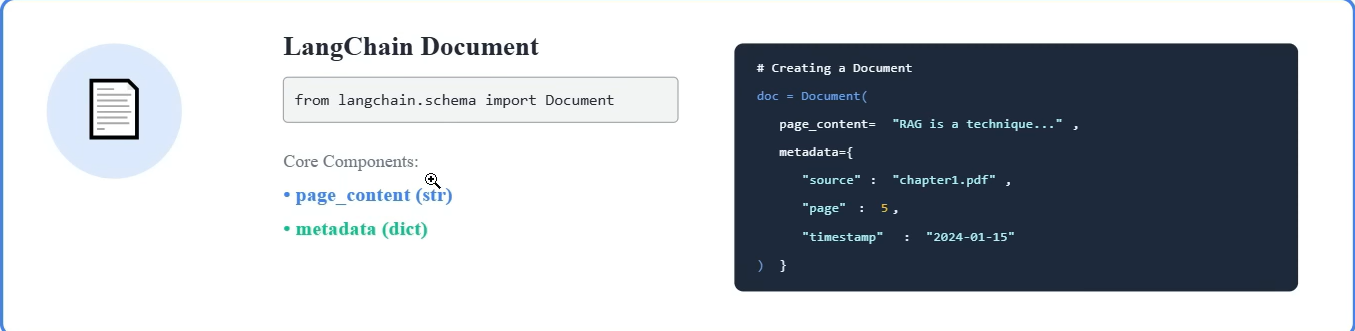

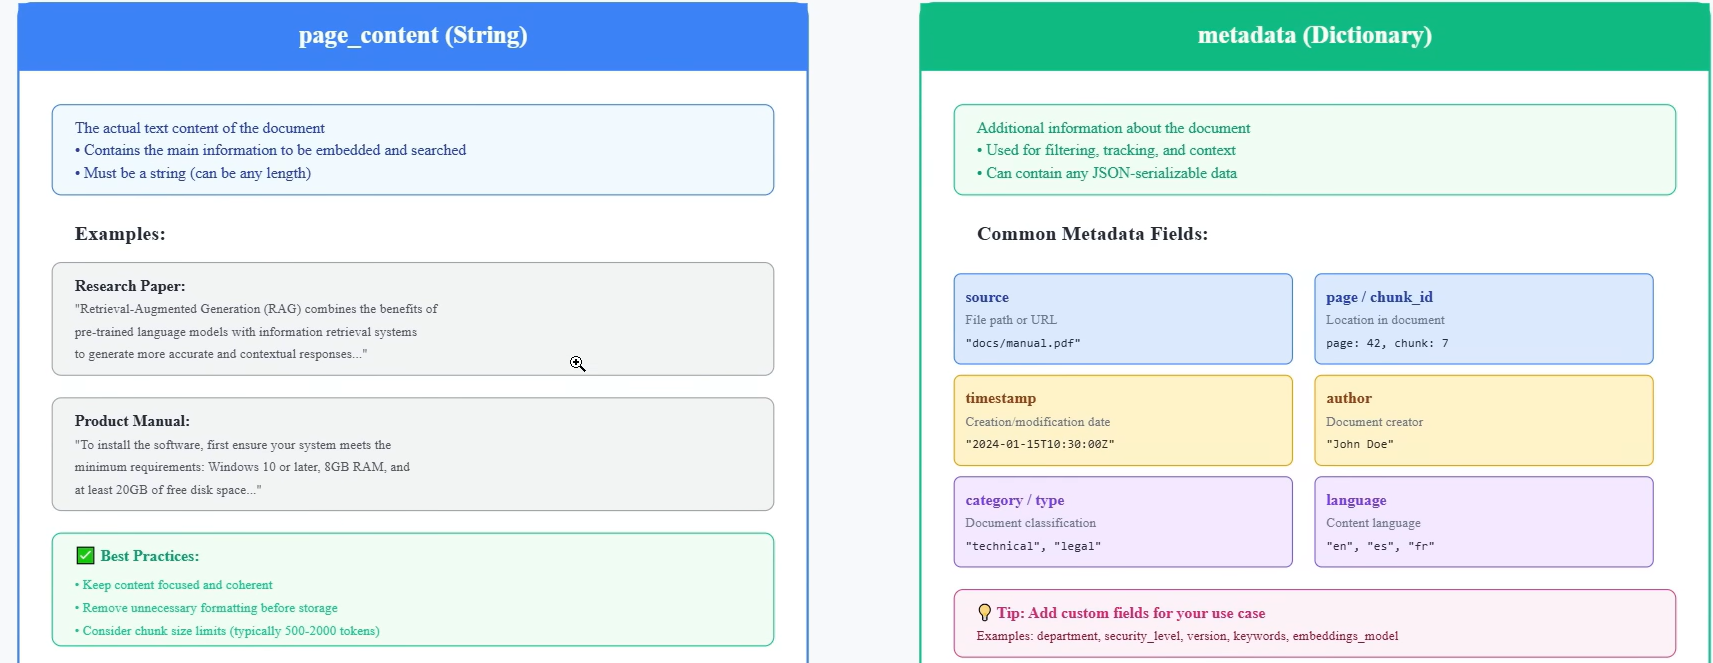

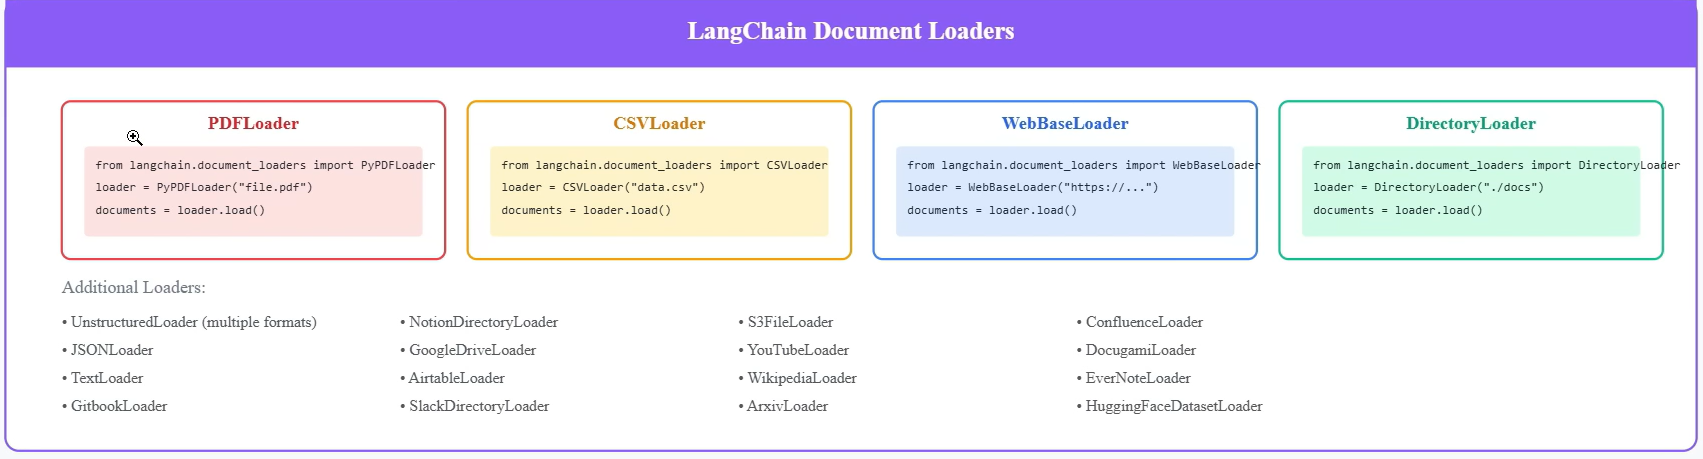


These loaders will load the data and at the end of the day these loaders will give you the output in the form of document structure.

In [3]:
### Manually creating the document structure

doc = Document(
    page_content = "This is the main text content I am using to create RAG.",
    metadata = {
        'source':"example.txt",
        "pages":1,
        "author":"AJ",
        "date_created":"2026-01-01"
    }
)

doc

## But along with page_content if you want to improve the source query retrieval from the vector DB, you need to also go ahead and write metadata.

## why all these metadata will be really really important because once we consider this document, once we do the chunking, once we do the embedding and once we store it into the vector DB.When you're doing the similarity search you can also apply filters that is the most important thing of this and when you apply filters , lets say I am searching what is the main text content for building the RAG some information is there and if I say by author AJ, I just add that particular filter then it knows which document to probably pick up because it is going to apply a filter using the name of the author.

Document(metadata={'source': 'example.txt', 'pages': 1, 'author': 'AJ', 'date_created': '2026-01-01'}, page_content='This is the main text content I am using to create RAG.')

In [4]:
## Create a simple txt file 
import os
os.makedirs("../data/text_files",exist_ok=True)

In [5]:
## manually creating a text file with the help of Python code

sample_texts={
    "../data/text_files/python_intro.txt":"""Python Programming Introduction

Python is a high-level, interpreted programming language known for its simplicity and readability.
Created by Guido van Rossum and first released in 1991, Python has become one of the most popular
programming languages in the world.

Key Features:
- Easy to learn and use
- Extensive standard library
- Cross-platform compatibility
- Strong community support

Python is widely used in web development, data science, artificial intelligence, and automation.""",
    
    "../data/text_files/machine_learning.txt": """Machine Learning Basics

Machine learning is a subset of artificial intelligence that enables systems to learn and improve
from experience without being explicitly programmed. It focuses on developing computer programs
that can access data and use it to learn for themselves.

Types of Machine Learning:
1. Supervised Learning: Learning with labeled data
2. Unsupervised Learning: Finding patterns in unlabeled data
3. Reinforcement Learning: Learning through rewards and penalties

Applications include image recognition, speech processing, and recommendation systems
    
    
    """

}

for filepath,content in sample_texts.items():
    with open(filepath,'w',encoding="utf-8") as f:
        f.write(content)

print("✅ Sample text files created!")

✅ Sample text files created!


In [6]:
### How to read using TextLoader

from langchain_community.document_loaders import TextLoader,PyPDFLoader

loader = TextLoader("../data/text_files/python_intro.txt",encoding="utf-8")
loader          # object of TextLoader
document = loader.load()
document

d:\RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Document(metadata={'source': '../data/text_files/python_intro.txt'}, page_content='Python Programming Introduction\n\nPython is a high-level, interpreted programming language known for its simplicity and readability.\nCreated by Guido van Rossum and first released in 1991, Python has become one of the most popular\nprogramming languages in the world.\n\nKey Features:\n- Easy to learn and use\n- Extensive standard library\n- Cross-platform compatibility\n- Strong community support\n\nPython is widely used in web development, data science, artificial intelligence, and automation.')]

See some of the metadata information has also got updated like what is the source right you can still go ahead and manually change more information inside the metadata but by default the best part is that whenever you are using this all libraries then also it will be able to give you the content in the document structure which is really really good because in the document structure you have two important things one is the metadata and one is the page content. So this is with respect to the TextLoader.

In [7]:
## Another way by Directory Loader
### If I have all the important files in my directory. Can I read it like that also or not? 

from langchain_community.document_loaders import DirectoryLoader

## load all the text files from the directory
dir_loader=DirectoryLoader(
    "../data/text_files",
    glob="**/*.txt", ## Pattern to match files  
    loader_cls= TextLoader, ##loader class to use  # TextLoader, PyPDFLoader,etc can be provided in the form of list
    loader_kwargs={'encoding': 'utf-8'},
    show_progress=False

)

documents=dir_loader.load()
documents

# from langchain_community.document_loaders import (
#     DirectoryLoader,
#     TextLoader,
#     PyPDFLoader
# )

# text_loader = DirectoryLoader(
#     "../data",
#     glob="**/*.txt",
#     loader_cls=TextLoader,
#     loader_kwargs={"encoding": "utf-8"},
# )

# pdf_loader = DirectoryLoader(
#     "../data",
#     glob="**/*.pdf",
#     loader_cls=PyPDFLoader,
# )

# documents = text_loader.load() + pdf_loader.load()

# documents

[Document(metadata={'source': '..\\data\\text_files\\Google.txt'}, page_content='\ufeffGoogle\nGoogle LLC (/ˈɡuːɡəl/ ⓘ , GOO-gəl) is an Google LLC\nAmerican multinational corporation and technology\ncompany focusing on online advertising, search engine\ntechnology, cloud computing, computer software,\nquantum computing, e-commerce, consumer\nelectronics, and artificial intelligence (AI).[9] It has\nbeen referred to as "the most powerful company in the The Google logo used since 2015\nworld" by the BBC[10] and is one of the world\'s most\nvaluable brands.[11][12][13] Google\'s parent company,\nAlphabet Inc., is one of the five Big Tech companies\nalongside Amazon, Apple, Meta, and Microsoft.\n\nGoogle was founded on September 4, 1998, by\nAmerican computer scientists Larry Page and Sergey\nBrin. Together, they own about 14% of its publicly\nlisted shares and control 56% of its stockholder voting\npower through super-voting stock. The company went\npublic via an initial public offering (

In [8]:
## For Loading Pdf
from langchain_community.document_loaders import PyMuPDFLoader

pdf_loader = DirectoryLoader(
    "../data/pdf_files",
    glob="**/*.pdf",
    loader_cls=PyMuPDFLoader,
    show_progress=False
)

pdf_documents=pdf_loader.load()
pdf_documents

[Document(metadata={'producer': 'ReportLab PDF Library - (opensource)', 'creator': '(unspecified)', 'creationdate': '2026-04-24T11:02:21+00:00', 'source': '..\\data\\pdf_files\\Anshita-Student-prompt.pdf', 'file_path': '..\\data\\pdf_files\\Anshita-Student-prompt.pdf', 'total_pages': 2, 'format': 'PDF 1.4', 'title': 'Anshita-Student-prompt', 'author': '(anonymous)', 'subject': '(unspecified)', 'keywords': '', 'moddate': '2026-04-24T11:02:21+00:00', 'trapped': '', 'modDate': "D:20260424110221+00'00'", 'creationDate': "D:20260424110221+00'00'", 'page': 0}, page_content="Anshita Jaiswal  •  Master Prompt  •  Confidential\nAnshita Jaiswal\nMSc Mathematics & Scientific Computing · NIT Warangal | GATE Statistics 2025 | JAM Statistics 2024 &\n2025\nData Scientist\nAI / ML Engineer\nAnalytics\nPlacement Ready\nABOUT ME\nI qualified GATE Statistics (2025) and JAM Statistics (2024 & 2025) entirely through self-study — my BSc was\nnot in statistics. I taught myself out of genuine curiosity and pa

We are getting these in the form of document structure, it is the list of document structure.

HW- Go to langchain documents loaders and u will be able to find out evreything over here. Just go in and try it out. For excel, db, etc

In [ ]:
type(pdf_documents[0])          # it is a document type

langchain_core.documents.base.Document

### Embedding and vectorstoreDB

In [ ]:
### faiss-cpu or chromadb --> is the database that we'll be using. these are the open source vector store

In [9]:
import numpy as np
from sentence_transformers import SentenceTransformer       ## embedding model will be available inside this
import chromadb
from chromadb.config import Settings
import uuid                                 ## the reason behind this uuid is because every record that we specifically insert into the vector db will have some kind of id over there. We'll generate that.
from typing import List, Dict, Any, Tuple
from sklearn.metrics.pairwise import cosine_similarity

In [1]:
class EmbeddingManager:
    """Handles document embedding generation using SentenceTransformer"""

    def __init__(self, model_name: str = "all-MiniLM-L6-v2"):       # :str → type hint saying this variable should contain a string
        """
        Initialize the embedding manager

        Args:
            model_name: HuggingFace model name for sentence embeddings
        """

        self.model_name = model_name
        self.model = None                   ## None -->No model loaded yet.
        self._load_model()          ## protected function --> within the class only it will be accessible.

    def _load_model(self):
        """Load the SentenceTransformer model"""
        try:
            print(f"Loading embedding model: {self.model_name}")
            self.model = SentenceTransformer(self.model_name)

            print(f"Model loaded successfully. Embedding dimension:{self.model.get_embedding_dimension()}")

        ## get_embedding_dimension() --> every text is converted to 384 dimensions. So once we have this init function we have the load model

        except Exception as e:
            print(f"Error loading model {self.model_name}: {e}")
            raise


    def generate_embeddings(self, texts: List[str]) -> np.ndarray:      #-> np.ndarray --> Return type hint.
    
        """
    Generate embeddings for a list of texts

    Args:
        texts: List of text strings to embed

    Returns:
        numpy array of embeddings with shape (len(texts), embedding_dim)
    """

        if not self.model:
            raise ValueError("Model not loaded")

        print(f"Generating embeddings for {len(texts)} texts...")
        embeddings = self.model.encode(texts, show_progress_bar=True)       #.encode()--> A method from the Sentence Transformers library. It converts text into embeddings.

        # show_progress_bar=True --> Batches: 100%|██████████| 10/10

        print(f"Generated embeddings with shape: {embeddings.shape}")

        return embeddings

    # def get_embedding_dimension(self) -> int:
    #     """Get the embedding dimension of the model"""

    #     if not self.model:
    #         raise ValueError("Model not loaded")

    #     return self.model.get_embedding_dimension()

    # we can write this above function in place of the up used function we can define it by ourselves

## Initializing the embedding manager

embedding_manager = EmbeddingManager()
embedding_manager


NameError: name 'List' is not defined

### VectorStore

In [ ]:
class VectorStore:
    """Manages document embeddings in a ChromaDB vector store"""

    def __init__(
        self,
        collection_name: str = "pdf_documents",
        persist_directory: str = "../data/vector_store"
    ):          # persist_directory --> whatever vector store is basically created we are going to save it that in the hard disk
        """
        Initialize the vector store

        Args:
            collection_name: Name of the ChromaDB collection
            persist_directory: Directory to persist the vector store
        """

        self.collection_name = collection_name
        self.persist_directory = persist_directory
        self.client = None                          # None --> Client not connected yet.
        self.collection = None                      # None --> Collection not created or loaded yet.

        self._initialize_store()                # initializing the store meaning that this function will be initializing the vector store itself.


    def _initialize_store(self):
        """Initialize ChromaDB client and collection"""
        
        try:
            # Create persistent ChromaDB client
            os.makedirs(self.persist_directory, exist_ok=True)

            self.client = chromadb.PersistentClient(
                path=self.persist_directory
            )           ## It is basically going to create a client which will be having a reference to the chromadb vector store.

            # Get or create collection
            self.collection = self.client.get_or_create_collection(
                name=self.collection_name,
                metadata={
                    "description": "PDF document embeddings for RAG"
                }
            )           ## collection is just like where we are going to store vectors inside my vector store, so it will be stored inside this vector collection(self.collection)

            print(
                f"Vector store initialized. Collection: "
                f"{self.collection_name}"
                )

            print(
                f"Existing documents in collection: "
                f"{self.collection.count()}"
                )

        except Exception as e:
            print(f"Error initializing vector store: {e}")
            raise

        ## now our chromadb client is ready and our collection will be created.

        ## The next function is that whenever we create a collection, now we need to add the documents. So we'll be creating another function for documents

    
    def add_documents(self, documents: List[Any], embeddings: np.ndarray):
        """
        Add documents and their embeddings to the vector store

        Args:
            documents: List of LangChain documents
            embeddings: Corresponding embeddings for the documents
        """
    

        if len(documents) != len(embeddings):
            raise ValueError("Number of documents must match number of embeddings")

        print(f"Adding {len(documents)} documents to vector store...")

        # Prepare data for ChromaDB
        ids = []
        metadatas = []
        documents_text = []
        embeddings_list = []

        for i, (doc, embedding) in enumerate(zip(documents, embeddings)):
            # Generate unique ID
            doc_id = f"doc_{uuid.uuid4().hex[:8]}_{i}"      ## creating a uuid for specific record --> doc id

            ids.append(doc_id)

        # Prepare metadata
        metadata = dict(doc.metadata)
        metadata['doc_index'] = i
        metadata['content_length'] = len(doc.page_content)
        metadatas.append(metadata)

        # Document content
        documents_text.append(doc.page_content)

        # Embedding
        embeddings_list.append(embedding.tolist())

        # Add to collection
        try:
            self.collection.add(
                ids=ids,
                embeddings=embeddings_list,
                metadatas=metadatas,
                documents=documents_text

            )
            print(f"Successfully added {len(documents)} documents to vector store")
            print(f"Total documents in collection: {self.collection.count()}")
            
        except Exception as e:
            print(f"Error adding documents to vector store: {e}")
            raise

vectorstore=VectorStore()
vectorstore
    



NameError: name 'List' is not defined